<a href="https://colab.research.google.com/github/youngPath12/AI-Health-Bio-Data-Team-4-Professor-yoon-/blob/Hyein-Yu/ADNI_Brain_Age_Gap_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADNI Brain Age Gap (BAG) 모델 개발

구조 MRI FreeSurfer ROI로 CN에서 뇌 연령을 학습하고, 편향 보정 BAG를 CN/MCI/AD에서 비교합니다. 개인 식별자(RID/PTID)는 결과 파일에 저장하지 않습니다.

> 이 노트북은 연구용 분석 예시이며 임상 진단 도구가 아닙니다. ADNI 데이터 사용계약을 준수하세요.

In [3]:
# Google Colab 기본 과학계산 패키지 사용
import os, re, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. 데이터 위치 설정
Google Drive에 `ADSP_PHC_T1_FS_22Jan2026.csv`를 업로드한 뒤 경로를 지정하세요. 처음 한 번만 Drive 마운트를 실행하면 됩니다.

In [5]:
# 필요 시 주석을 해제하고 Drive를 마운트하세요.
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = Path('/content/drive/MyDrive/ADNI_project/ADSP_PHC_T1_FS_22Jan2026.csv')
# 예: DATA_PATH = Path('/content/ADSP_PHC_T1_FS_22Jan2026.csv')
RESULT_DIR = Path('/content/brain_age_results')
RESULT_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), f'파일을 찾지 못했습니다: {DATA_PATH}'
print('입력:', DATA_PATH)
print('결과:', RESULT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
입력: /content/drive/MyDrive/ADNI_project/ADSP_PHC_T1_FS_22Jan2026.csv
결과: /content/brain_age_results


In [6]:
# CSV 로드 및 실제 변수 확인
df = pd.read_csv(DATA_PATH, low_memory=False)
print('원본 행/열:', df.shape)
print('진단 코드별 검사 수:\n', df['PHC_Diagnosis'].value_counts(dropna=False).sort_index())

required = ['RID', 'PHC_SCANDATE', 'PHC_Age_T1', 'PHC_Sex', 'PHC_Diagnosis']
missing = sorted(set(required) - set(df.columns))
assert not missing, f'필수 열 누락: {missing}'
roi_cols = [c for c in df.columns if c.endswith('_combat')]
assert len(roi_cols) > 0, '*_combat ROI 열을 찾지 못했습니다.'
icv_candidates = [c for c in roi_cols if 'EstimatedTotalIntraCranialVol' in c]
ICV_COL = icv_candidates[0] if icv_candidates else None
print(f'선택된 ROI: {len(roi_cols)}개 | ICV: {ICV_COL}')

원본 행/열: (10260, 212)
진단 코드별 검사 수:
 PHC_Diagnosis
1.0    3311
2.0    3837
3.0    1618
NaN    1494
Name: count, dtype: int64
선택된 ROI: 192개 | ICV: EstimatedTotalIntraCranialVol_combat


## 2. 코호트 구성
문서 및 데이터 분포에 맞춰 `1=CN, 2=MCI, 3=AD`로 설정했습니다. 데이터 사전과 다르면 아래 사전을 수정하세요. 참가자당 가장 이른 유효 T1 검사 1개만 사용해 방문 간 누수를 막습니다.

In [7]:
DIAGNOSIS_MAP = {1: 'CN', 2: 'MCI', 3: 'AD'}  # 데이터 사전으로 반드시 확인
SEX_MAP = {1: 'Male', 2: 'Female'}

work = df[required + roi_cols].copy()
work['diagnosis'] = pd.to_numeric(work['PHC_Diagnosis'], errors='coerce').map(DIAGNOSIS_MAP)
work['sex'] = pd.to_numeric(work['PHC_Sex'], errors='coerce').map(SEX_MAP).fillna('Unknown')
work['age'] = pd.to_numeric(work['PHC_Age_T1'], errors='coerce')
work['scan_date'] = pd.to_datetime(work['PHC_SCANDATE'], errors='coerce')
for col in roi_cols:
    work[col] = pd.to_numeric(work[col], errors='coerce')

# 진단/나이/RID가 유효한 가장 이른 검사만 유지
work = work.dropna(subset=['RID', 'diagnosis', 'age']).sort_values(['RID', 'scan_date'])
work = work.drop_duplicates('RID', keep='first').reset_index(drop=True)
print('1인 1검사 코호트:', work.shape)
print(work['diagnosis'].value_counts())
assert set(work['diagnosis'].unique()) <= {'CN', 'MCI', 'AD'}

1인 1검사 코호트: (2385, 201)
diagnosis
MCI    1088
CN      911
AD      386
Name: count, dtype: int64


## 3. CN 그룹 분할과 모델 학습
RID 단위로 70%/15%/15% train/validation/test로 나눕니다. Ridge와 HistGradientBoosting을 검증 MAE로 비교합니다. 결측치 대치·표준화는 파이프라인 내부에서 학습 데이터에만 fit됩니다.

In [8]:
cn = work.query("diagnosis == 'CN'").copy()
assert len(cn) >= 100, 'CN 표본이 너무 적습니다.'

def grouped_split(frame, test_size, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(splitter.split(frame, groups=frame['RID']))
    return frame.iloc[train_idx].copy(), frame.iloc[test_idx].copy()

cn_train, cn_holdout = grouped_split(cn, test_size=0.30, seed=RANDOM_STATE)
cn_val, cn_test = grouped_split(cn_holdout, test_size=0.50, seed=RANDOM_STATE + 1)
assert set(cn_train.RID).isdisjoint(cn_val.RID) and set(cn_train.RID).isdisjoint(cn_test.RID)
print({k: len(v) for k, v in {'train':cn_train, 'val':cn_val, 'test':cn_test}.items()})

# ROI와 성별을 입력으로 사용. ICV도 ROI 안에 포함되므로 중복 추가하지 않습니다.
feature_cols = roi_cols + ['sex']
numeric_features, categorical_features = roi_cols, ['sex']
preprocess = ColumnTransformer([
    ('roi', Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)),
                      ('scaler', StandardScaler())]), numeric_features),
    ('sex', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

models = {
    'Ridge': Pipeline([('preprocess', preprocess), ('model', Ridge(alpha=30.0))]),
    'HistGradientBoosting': Pipeline([('preprocess', preprocess),
       ('model', HistGradientBoostingRegressor(max_iter=250, learning_rate=0.04,
        max_leaf_nodes=12, l2_regularization=2.0, random_state=RANDOM_STATE))])
}

validation_rows = []
for name, model in models.items():
    model.fit(cn_train[feature_cols], cn_train['age'])
    pred = model.predict(cn_val[feature_cols])
    validation_rows.append({'model': name, 'MAE': mean_absolute_error(cn_val.age, pred),
                            'RMSE': mean_squared_error(cn_val.age, pred)**0.5,
                            'R2': r2_score(cn_val.age, pred)})
validation = pd.DataFrame(validation_rows).sort_values('MAE').reset_index(drop=True)
display(validation)
best_name = validation.loc[0, 'model']
print('선택 모델:', best_name)

{'train': 637, 'val': 137, 'test': 137}


,model,MAE,RMSE,R2
0,Ridge,3.892696,5.024086,0.368788
1,HistGradientBoosting,4.049999,5.117478,0.345103


선택 모델: Ridge


Bias correction: predicted_age = 31.409 + 0.574 × chronological_age


,model,n_CN_test,MAE_raw,MAE_corrected,RMSE_raw,R2_raw
0,Ridge,137,3.677516,5.388947,4.805447,0.465338


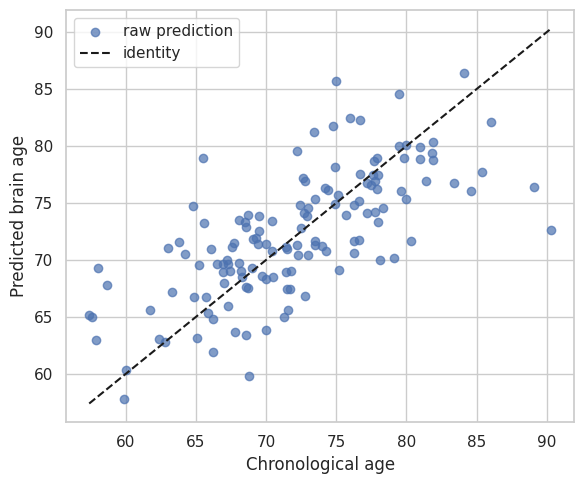

In [9]:
# train+validation으로 최종 재학습; 검증 CN 예측으로 연령 편향 보정 계수를 추정
best_model = models[best_name]
best_model.fit(cn_train[feature_cols], cn_train['age'])
val_pred = best_model.predict(cn_val[feature_cols])
bias_fit = LinearRegression().fit(cn_val[['age']], val_pred)
a, b = float(bias_fit.intercept_), float(bias_fit.coef_[0])
assert abs(b) > 1e-6, '편향 보정 기울기가 0에 가깝습니다.'
print(f'Bias correction: predicted_age = {a:.3f} + {b:.3f} × chronological_age')

final_cn = pd.concat([cn_train, cn_val], ignore_index=True)
best_model.fit(final_cn[feature_cols], final_cn['age'])
test_pred = best_model.predict(cn_test[feature_cols])
test_corrected = (test_pred - a) / b
metrics = pd.DataFrame([{
    'model': best_name, 'n_CN_test': len(cn_test),
    'MAE_raw': mean_absolute_error(cn_test.age, test_pred),
    'MAE_corrected': mean_absolute_error(cn_test.age, test_corrected),
    'RMSE_raw': mean_squared_error(cn_test.age, test_pred)**0.5,
    'R2_raw': r2_score(cn_test.age, test_pred)
}])
display(metrics)

plt.figure(figsize=(6, 5))
plt.scatter(cn_test.age, test_pred, alpha=.7, label='raw prediction')
lims = [min(cn_test.age.min(), test_pred.min()), max(cn_test.age.max(), test_pred.max())]
plt.plot(lims, lims, 'k--', label='identity')
plt.xlabel('Chronological age'); plt.ylabel('Predicted brain age'); plt.legend(); plt.tight_layout()
plt.savefig(RESULT_DIR / 'cn_test_prediction.png', dpi=180); plt.show()

## 4. Corrected BAG 및 진단군 비교
보정식은 검증 CN에서만 추정하고, 동일 계수를 모든 진단군에 적용합니다. 주 분석은 `Corrected BAG ~ diagnosis + age + sex + ICV` OLS입니다.

                            OLS Regression Results                            
Dep. Variable:          corrected_BAG   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     118.5
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          3.44e-112
Time:                        01:34:20   Log-Likelihood:                -8214.6
No. Observations:                2385   AIC:                         1.644e+04
Df Residuals:                    2379   BIC:                         1.648e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

,diagnosis,count,mean,std,median
0,CN,911,-1.081615,5.810455,-1.174000
1,MCI,1088,3.393905,8.357998,2.963731
2,AD,386,9.438866,9.804556,8.976050


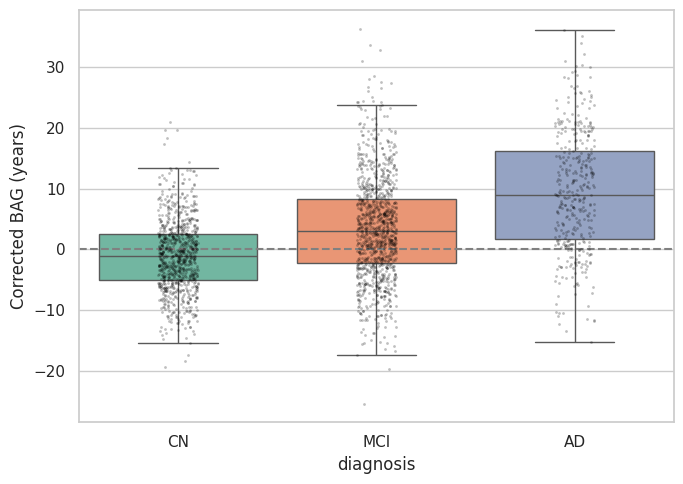

In [10]:
analysis = work.copy()
analysis['predicted_age'] = best_model.predict(analysis[feature_cols])
analysis['corrected_predicted_age'] = (analysis['predicted_age'] - a) / b
analysis['raw_BAG'] = analysis['predicted_age'] - analysis['age']
analysis['corrected_BAG'] = analysis['corrected_predicted_age'] - analysis['age']
analysis['diagnosis'] = pd.Categorical(analysis['diagnosis'], categories=['CN', 'MCI', 'AD'], ordered=True)

formula = 'corrected_BAG ~ C(diagnosis, Treatment(reference="CN")) + age + C(sex)'
if ICV_COL is not None:
    formula += f' + Q("{ICV_COL}")'
ancova = smf.ols(formula, data=analysis).fit(cov_type='HC3')
print(ancova.summary())

group_summary = analysis.groupby('diagnosis', observed=True)['corrected_BAG'].agg(['count','mean','std','median']).reset_index()
display(group_summary)
plt.figure(figsize=(7, 5))
sns.boxplot(data=analysis, x='diagnosis', y='corrected_BAG', palette='Set2', showfliers=False)
sns.stripplot(data=analysis, x='diagnosis', y='corrected_BAG', color='black', alpha=.25, size=2)
plt.axhline(0, color='gray', ls='--'); plt.ylabel('Corrected BAG (years)'); plt.tight_layout()
plt.savefig(RESULT_DIR / 'bag_by_diagnosis.png', dpi=180); plt.show()

## 5. ROI별 노화 부담 점수
CN에서 ROI별 기대값(나이·성별·ICV)을 적합합니다. 피질 두께·일반 부피는 낮을수록, 뇌실 ROI는 클수록 높은 부담이 되도록 부호를 통일합니다. 이는 ROI/atlas 수준의 상대적 구조 편차이며 voxel 병변 지도는 아닙니다.

,ROI,AD_mean_burden_z
0,Right.Inf.Lat.Vent_combat,2.232047
1,lh_entorhinal_thickness_combat,2.149603
2,Left.Hippocampus_combat,2.061021
3,rh_entorhinal_thickness_combat,1.959033
4,Right.Hippocampus_combat,1.929930
5,Left.Inf.Lat.Vent_combat,1.916444
6,Left.Amygdala_combat,1.808832
7,Right.Amygdala_combat,1.749835
8,lh_middletemporal_thickness_combat,1.650470
9,rh_middletemporal_thickness_combat,1.602170


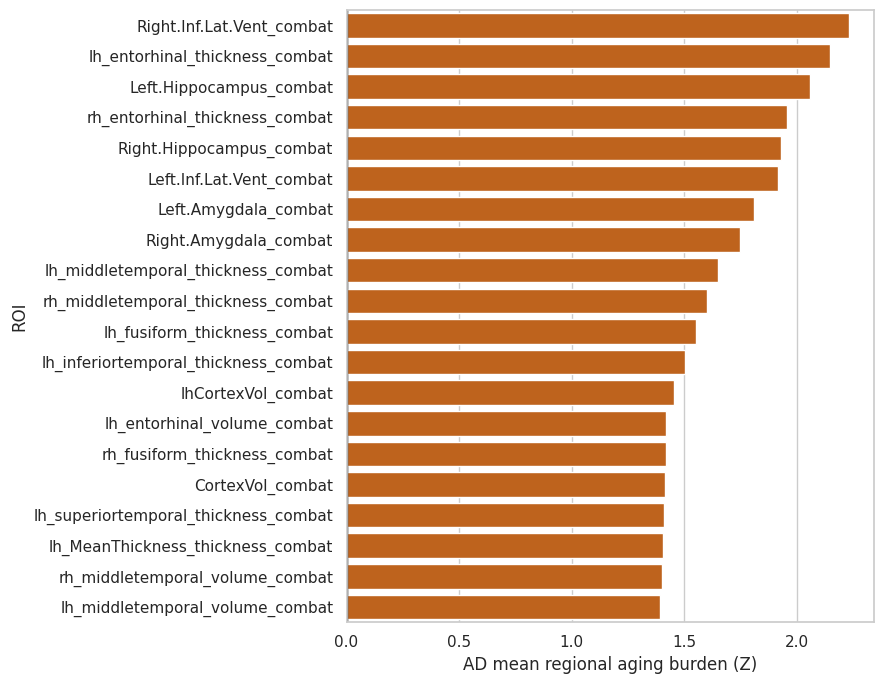

In [14]:
NORMATIVE_ROIS = roi_cols
ventricle_pattern = re.compile(r'ventricle|ventricle|3rd\.Ventricle|4th\.Ventricle|Inf\.Lat\.Vent', re.I)
normative = analysis[['RID', 'diagnosis', 'age', 'sex'] + NORMATIVE_ROIS].copy()
cn_norm = normative.query("diagnosis == 'CN'")
burden = pd.DataFrame(index=analysis.index)
for roi in NORMATIVE_ROIS:
    cols_for_train_roi = ['age', 'sex', roi]
    current_roi_formula = f'Q("{roi}") ~ age + C(sex)'

    if ICV_COL and ICV_COL != roi:
        cols_for_train_roi.append(ICV_COL)
        current_roi_formula += f' + Q("{ICV_COL}")'

    train_roi = cn_norm[cols_for_train_roi].dropna()
    if len(train_roi) < 50:
        continue

    fit = smf.ols(current_roi_formula, data=train_roi).fit()
    residual_sd = fit.resid.std(ddof=int(fit.df_model) + 1)
    expected = fit.predict(analysis)
    z = (analysis[roi] - expected) / residual_sd
    # ventricle expansion is adverse; other thickness/volume reductions are adverse
    burden[roi] = z if ventricle_pattern.search(roi) else -z

analysis = pd.concat([analysis, burden.add_prefix('burden_')], axis=1)
mean_burden = pd.DataFrame({
    d: burden.loc[analysis.diagnosis == d].mean() for d in ['CN', 'MCI', 'AD']
})
top_ad = mean_burden['AD'].sort_values(ascending=False).head(20).reset_index()
top_ad.columns = ['ROI', 'AD_mean_burden_z']
display(top_ad)
plt.figure(figsize=(9, 7))
sns.barplot(data=top_ad, y='ROI', x='AD_mean_burden_z', color='#d95f02')
plt.axvline(0, color='black', lw=1); plt.xlabel('AD mean regional aging burden (Z)'); plt.tight_layout()
plt.savefig(RESULT_DIR / 'top_ad_roi_burden.png', dpi=180); plt.show()

In [15]:
# 식별자를 제외한 재현성 산출물 저장
safe_columns = ['diagnosis', 'age', 'sex', 'predicted_age', 'corrected_predicted_age', 'raw_BAG', 'corrected_BAG']
analysis[safe_columns].to_csv(RESULT_DIR / 'bag_results_deidentified.csv', index=False)
validation.to_csv(RESULT_DIR / 'validation_model_comparison.csv', index=False)
metrics.to_csv(RESULT_DIR / 'cn_test_metrics.csv', index=False)
group_summary.to_csv(RESULT_DIR / 'bag_group_summary.csv', index=False)
top_ad.to_csv(RESULT_DIR / 'top_ad_roi_burden.csv', index=False)
with open(RESULT_DIR / 'run_metadata.json', 'w') as f:
    json.dump({'random_state': RANDOM_STATE, 'selected_model': best_name,
               'bias_intercept_a': a, 'bias_slope_b': b, 'n_roi_features': len(roi_cols),
               'diagnosis_map': DIAGNOSIS_MAP}, f, indent=2)
print('저장 완료:', RESULT_DIR)
print(sorted(p.name for p in RESULT_DIR.iterdir()))

저장 완료: /content/brain_age_results
['bag_by_diagnosis.png', 'bag_group_summary.csv', 'bag_results_deidentified.csv', 'cn_test_metrics.csv', 'cn_test_prediction.png', 'run_metadata.json', 'top_ad_roi_burden.csv', 'top_ad_roi_burden.png', 'validation_model_comparison.csv']
